# 07 Comparison
**Part 1: Reproduction.** Reported (paper) vs Ours, same dataset, folds and metrics.


**Part 2: Extension.** XGBoost (not in the paper) vs the reference models, same dataset, folds and metrics.
Reported values come from the paper (linear SVM, custom kernel, decision tree) and the author's notebook (bagged DT at 100 trees; the paper only shows a plot).

In [1]:
!git clone https://github.com/rosa36-x/funko-ml.git
%cd funko-ml/notebooks
!ls ../data ../src

Cloning into 'funko-ml'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (81/81), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 81 (delta 41), reused 31 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (81/81), 239.04 KiB | 7.71 MiB/s, done.
Resolving deltas: 100% (41/41), done.
/content/funko-ml/notebooks
../data:
data_curated.csv  folds.pkl  processed.npz  processed_table.csv

../src:
evaluate.py  __init__.py


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.width', 250)
R = '../results'
rd = lambda f: pd.read_csv(f'{R}/{f}.csv')
svm_linear, svm_rbf, svm_custom = rd('svm_linear'), rd('svm_rbf'), rd('svm_custom_kernel')
dt, bag, xgb = rd('decision_tree'), rd('bagged_dt'), rd('xgboost')
bag100 = bag[bag['num_trees'] == 100]

## Part 1: Reproduce the reported results

In [3]:
# (precision, recall, f1)
reported = {
    'Linear SVM':        dict(valid=(0.408, 0.482, 0.440), train=(0.625, 0.608, 0.576)),
    'Custom-kernel SVM': dict(valid=(0.390, 0.460, 0.421), train=(0.662, 0.630, 0.602)),
    'Decision tree':     dict(valid=(0.408, 0.415, 0.409), train=(0.984, 0.983, 0.983)),
    'Bagged DT (100)':   dict(valid=(0.452, 0.476, 0.456), train=None),
}
ours = {'Linear SVM': svm_linear, 'Custom-kernel SVM': svm_custom,
        'Decision tree': dt, 'Bagged DT (100)': bag100}

rows = []
for m, rep in reported.items():
    o = ours[m].iloc[0]
    for split in ['valid', 'train']:
        if rep[split] is None:
            continue
        row = {'model': m, 'split': split}
        for k, name in enumerate(['precision', 'recall', 'f1']):
            row[f'{name}_reported'] = rep[split][k]
            row[f'{name}_ours'] = round(float(o[f'{split}_{name}']), 3)
            row[f'{name}_diff'] = round(row[f'{name}_ours'] - rep[split][k], 3)
        rows.append(row)
t1 = pd.DataFrame(rows)

In [4]:
t1[t1['split'] == 'valid']

,model,split,precision_reported,precision_ours,precision_diff,recall_reported,recall_ours,recall_diff,f1_reported,f1_ours,f1_diff
0,Linear SVM,valid,0.408,0.408,0.000,0.482,0.482,0.000,0.440,0.440,0.000
2,Custom-kernel SVM,valid,0.390,0.392,0.002,0.460,0.462,0.002,0.421,0.423,0.002
4,Decision tree,valid,0.408,0.408,0.000,0.415,0.415,0.000,0.409,0.409,0.000
6,Bagged DT (100),valid,0.452,0.452,0.000,0.476,0.476,0.000,0.456,0.456,0.000


In [5]:
t1[t1['split'] == 'train']

,model,split,precision_reported,precision_ours,precision_diff,recall_reported,recall_ours,recall_diff,f1_reported,f1_ours,f1_diff
1,Linear SVM,train,0.625,0.625,0.000,0.608,0.608,0.000,0.576,0.576,0.000
3,Custom-kernel SVM,train,0.662,0.624,-0.038,0.630,0.605,-0.025,0.602,0.574,-0.028
5,Decision tree,train,0.984,0.984,0.000,0.983,0.983,0.000,0.983,0.983,0.000


In [6]:
rep_cls = {'Linear SVM': [0.498, 0.482, 0, 0, 0],
           'Custom-kernel SVM': [0.485, 0.453, 0, 0, 0],
           'Decision tree': [0.477, 0.452, 0.137, 0, 0.333]}
bins = [f'Bin {i}' for i in range(1, 6)]

rows = []
for m, rep in rep_cls.items():
    o = [round(float(ours[m].iloc[0][f'valid_bin{i}_precision']), 3) for i in range(1, 6)]
    rows.append([m, 'reported'] + rep)
    rows.append([m, 'ours'] + o)
    rows.append([m, 'diff'] + [round(a - b, 3) for a, b in zip(o, rep)])

t2 = pd.DataFrame(rows, columns=['model', 'source'] + bins).set_index(['model', 'source'])
t2.style.format('{:.3f}').apply(
    lambda r: ['font-weight: bold' if r.name[1] == 'diff' else '' for _ in r], axis=1)

In [7]:
print(f"RBF valid F1 {svm_rbf.iloc[0]['valid_f1']:.3f} vs linear {svm_linear.iloc[0]['valid_f1']:.3f}")

RBF valid F1 0.438 vs linear 0.440


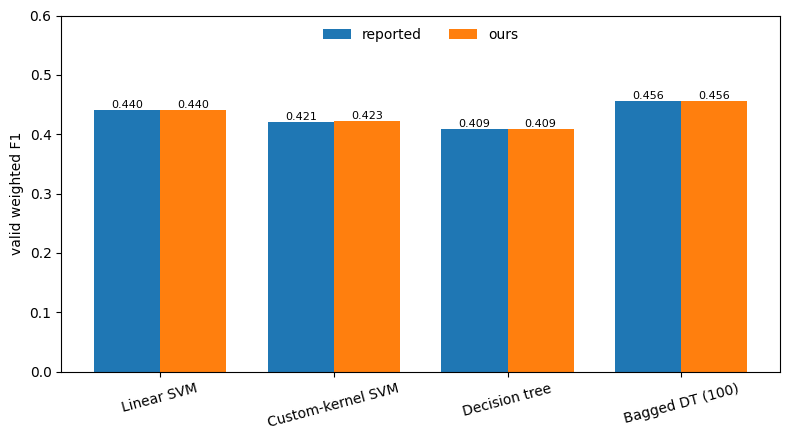

In [8]:
v = t1[t1['split'] == 'valid'].reset_index(drop=True)
x, w = np.arange(len(v)), 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, v['f1_reported'], w, label='reported', color='tab:blue')
ax.bar(x + w/2, v['f1_ours'], w, label='ours', color='tab:orange')
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(v['model'], rotation=15)
ax.set_ylabel('valid weighted F1'); ax.set_ylim(0, 0.6)
ax.legend(loc='upper center', ncol=2, frameon=False)
plt.tight_layout(); plt.savefig('../results/comparison_reproduction.png', dpi=150); plt.show()

- Linear SVM and bagged DT reproduce exactly (valid F1 0.440, 0.456).
- Custom-kernel SVM: valid F1 0.423 vs 0.421 (within 0.002). Train F1 0.574 vs 0.602: the paper does not give alpha, theta or C, so a gap on train is expected.
- Decision tree: valid F1 0.409 vs 0.409, an exact match once the seed is fixed (random_state=1). Without a fixed seed, ties between equally good splits are broken randomly, and our unseeded run gave 0.399.
- Decision tree per-class precision matches the paper in every bin (bin 3: 0.136 vs 0.137, a rounding-level difference). Bin 5 (4 items) is 0.333, as reported; it is still the least stable number, since one prediction changes it.
- Other sources of small differences: fold seed, library versions.

## Part 2: Extension model (XGBoost)
Why XGBoost: the paper's single trees overfit badly (train F1 0.98 vs valid 0.41), and bagging only reduces variance. Boosting builds trees
sequentially on errors, supports class-weighted training for the rare high-price bins, and works with one-hot features without scaling.
It is not used in the paper, and it was trained on the same features, the same 4 folds and the same metrics.

In [9]:
allm = pd.concat([svm_linear, svm_rbf, svm_custom, dt, bag100, xgb], ignore_index=True)
ext = allm[['model', 'train_f1', 'valid_precision', 'valid_recall', 'valid_f1',
            'valid_bin3_precision', 'valid_bin4_precision', 'valid_bin5_precision']].copy()
ext['train_valid_gap'] = (ext['train_f1'] - ext['valid_f1']).round(3)
ext = ext.sort_values('valid_f1', ascending=False).reset_index(drop=True)
ext

,model,train_f1,valid_precision,valid_recall,valid_f1,valid_bin3_precision,valid_bin4_precision,valid_bin5_precision,train_valid_gap
0,bagged_dt,0.9833,0.4522,0.4764,0.4557,0.3006,0.0000,0.0000,0.528
1,xgboost_shallow,0.7085,0.4483,0.4820,0.4537,0.3083,0.0000,0.0000,0.255
2,xgboost,0.9618,0.4519,0.4594,0.4521,0.3289,0.3750,0.0000,0.510
3,xgboost_balanced,0.9294,0.4575,0.4512,0.4510,0.2105,0.5625,0.0000,0.478
4,svm_linear,0.5763,0.4077,0.4819,0.4404,0.0000,0.0000,0.0000,0.136
5,svm_rbf,0.5652,0.4027,0.4821,0.4382,0.0000,0.0000,0.0000,0.127
6,xgboost_shallow_balanced,0.7025,0.4509,0.4262,0.4335,0.1849,0.1833,0.0000,0.269
7,svm_custom_kernel,0.5737,0.3916,0.4624,0.4229,0.0000,0.0000,0.0000,0.151
8,decision_tree,0.9833,0.4079,0.4151,0.4089,0.1364,0.0000,0.3333,0.574


In [10]:
THRESH = 0.02   # per-fold valid F1 varies by ~0.03-0.08, so gaps under 0.02 are treated as "similar"
xg = xgb[xgb['model'] == 'xgboost'].iloc[0]
refs = {'Linear SVM': svm_linear, 'RBF SVM': svm_rbf, 'Custom-kernel SVM': svm_custom,
        'Decision tree': dt, 'Bagged DT (100)': bag100}
rows = []
for m, r in refs.items():
    r = r.iloc[0]
    d = xg['valid_f1'] - r['valid_f1']
    rows.append({'reference model': m,
                 'ref_valid_f1': round(r['valid_f1'], 3),
                 'xgboost_valid_f1': round(xg['valid_f1'], 3),
                 'diff': round(d, 3),
                 'verdict': 'better' if d > THRESH else 'worse' if d < -THRESH else 'similar',
                 'ref_bin4_prec': round(r['valid_bin4_precision'], 3),
                 'xgb_bin4_prec': round(xg['valid_bin4_precision'], 3)})
t3 = pd.DataFrame(rows)
t3

,reference model,ref_valid_f1,xgboost_valid_f1,diff,verdict,ref_bin4_prec,xgb_bin4_prec
0,Linear SVM,0.440,0.452,0.012,similar,0.0,0.375
1,RBF SVM,0.438,0.452,0.014,similar,0.0,0.375
2,Custom-kernel SVM,0.423,0.452,0.029,better,0.0,0.375
3,Decision tree,0.409,0.452,0.043,better,0.0,0.375
4,Bagged DT (100),0.456,0.452,-0.004,similar,0.0,0.375


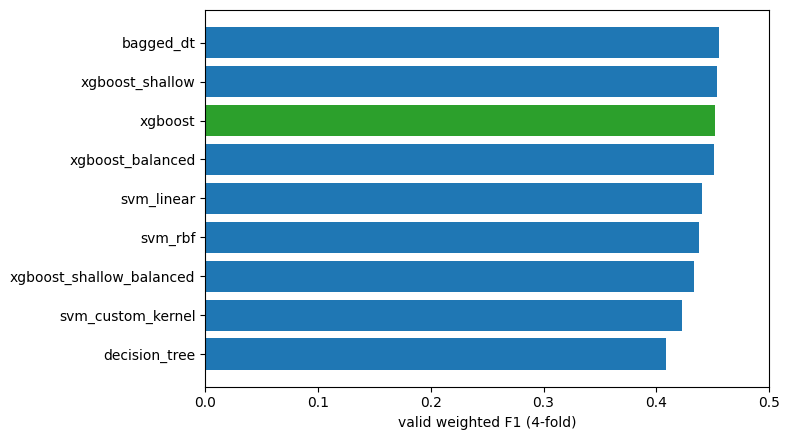

In [11]:
plt.figure(figsize=(8, 4.5))
cols = ['tab:green' if m == 'xgboost' else 'tab:blue' for m in ext['model']]
plt.barh(ext['model'][::-1], ext['valid_f1'][::-1], color=cols[::-1])
plt.xlabel('valid weighted F1 (4-fold)'); plt.xlim(0, 0.5); plt.tight_layout()
plt.savefig('../results/comparison_extension.png', dpi=150); plt.show()

- Better than the paper's single models: +0.03 over the custom-kernel SVM, +0.04-0.05 over the decision tree.
- Similar to linear/RBF SVM (+0.01) and to bagged DT (-0.004), all within fold noise.
- Why: boosting reduces the single tree's variance like bagging does, so the two end up equal. Both are limited by 359 items and four weak features, as the paper concludes.
- XGBoost is the only model with nonzero bin 4 precision (0.375, 10 items in that bin); bin 5 (4 items) is 0 for every model. Treat this as suggestive, not conclusive.

In [12]:
t1.to_csv('../results/comparison_reported_vs_ours.csv', index=False)
ext.to_csv('../results/comparison_extension.csv', index=False)
t3.to_csv('../results/comparison_xgboost_vs_reference.csv', index=False)

In [13]:
from google.colab import files
import glob
for f in sorted(glob.glob('../results/comparison_*')):
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>